In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv('../data/raw/sentiment-emotion-labelled_Dell_tweets.csv')

#Cancellazione della prima colonna
df.drop(columns=df.columns[0], axis = 1, inplace=True)
print(f"Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne\n")
print(f"\nColonne presenti:")
print(df.columns.tolist())
print(f"\nTipi di dato:")
print(df.dtypes)
print(f"\nPrime 5 righe:")
df.head()

Dimensioni: 24970 righe, 8 colonne


Colonne presenti:
['Datetime', 'Tweet Id', 'Text', 'Username', 'sentiment', 'sentiment_score', 'emotion', 'emotion_score']

Tipi di dato:
Datetime            object
Tweet Id             int64
Text                object
Username            object
sentiment           object
sentiment_score    float64
emotion             object
emotion_score      float64
dtype: object

Prime 5 righe:


,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
0,2022-09-30 23:29:15+00:00,1575991191170342912,@Logitech @apple @Google @Microsoft @Dell @Len...,ManjuSreedaran,neutral,0.853283,anticipation,0.587121
1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat...,MiKeMcDnet,neutral,0.519470,joy,0.886913
2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob F...",jfollett,positive,0.763791,joy,0.960347
3,2022-09-30 20:05:24+00:00,1575939891485032450,@dell your customer service is horrible especi...,daveccarr,negative,0.954023,anger,0.983203
4,2022-09-30 20:03:17+00:00,1575939359160750080,@zacokalo @Dell @DellCares @Dell give the man ...,heycamella,neutral,0.529170,anger,0.776124


Valutazione dei NaN e Tweet duplicati

In [3]:
#Valori null
print("VALORI MANCANTI:")
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNessun valore mancante!")

#Duplicati
print("\nDUPLICATI:")
print(f"Righe duplicate: {df.duplicated().sum()}")
print(f"Tweet duplicati (stesso testo): {df['Text'].duplicated().sum()}")
print(f"Tweet ID duplicati: {df['Tweet Id'].duplicated().sum()}")

#Mostra esempi di duplicati
if df['Text'].duplicated().sum() > 0:
    print("\n Esempi di tweet duplicati:")
    dup_mask = df['Text'].duplicated(keep=False)
    print(df[dup_mask][['Text', 'sentiment', 'emotion']].head(6))

print("\nRIMOZIONE DUPLICATI")

#Rimozione duplicati basata sul testo
df_clean = df.drop_duplicates(subset='Text', keep='first')

#Statistiche dopo la rimozione
print(f"Dataset dopo rimozione duplicati: {len(df_clean)} righe")
print(f"Righe rimosse: {len(df) - len(df_clean)}")
print(f"Percentuale dati mantenuti: {len(df_clean)/len(df)*100:.2f}%")

print(f"Verifica: Tweet duplicati rimasti: {df_clean['Text'].duplicated().sum()}")

df = df_clean

VALORI MANCANTI:
Datetime           0
Tweet Id           0
Text               0
Username           0
sentiment          0
sentiment_score    0
emotion            0
emotion_score      0
dtype: int64

Nessun valore mancante!

DUPLICATI:
Righe duplicate: 0
Tweet duplicati (stesso testo): 331
Tweet ID duplicati: 0

 Esempi di tweet duplicati:
                                                  Text sentiment  emotion
32   @ashu_k7 @Dell Pathetic!!!!! I Dont mind takin...  negative    anger
36   @ashu_k7 @Dell Pathetic!!!!! I Dont mind takin...  negative    anger
68                             @Dell That’s very great  positive      joy
154                              @Dell This is amazing  positive      joy
269             @Dell Bad product Dell Inspiron laptop  negative  disgust
270             @Dell Bad product Dell Inspiron laptop  negative  disgust

RIMOZIONE DUPLICATI
Dataset dopo rimozione duplicati: 24639 righe
Righe rimosse: 331
Percentuale dati mantenuti: 98.67%
Verifica: Tweet dupl

Grafico a torta per distribuzione dei Sentiment

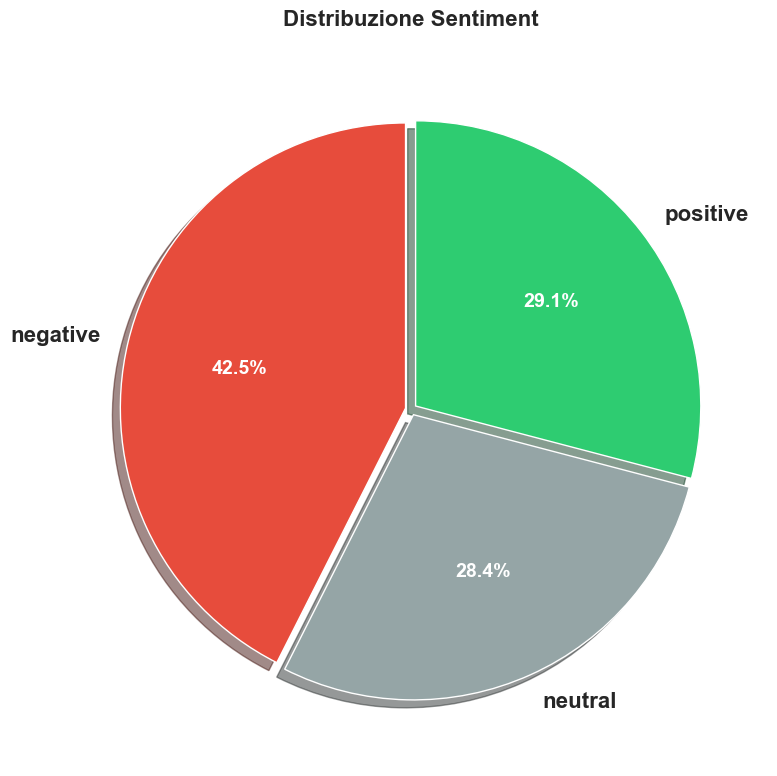

In [4]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

sentiment_order = ['negative', 'neutral', 'positive']
sentiment_counts = df['sentiment'].value_counts().reindex(sentiment_order)

colors = ['#e74c3c', '#95a5a6', '#2ecc71']
fig, ax = plt.subplots(figsize=(10, 8))

#Creazione del grafico con esplosione della torta
explode = (0.02, 0.02, 0.02)  

wedges, texts, autotexts = ax.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,  
    textprops={'fontsize': 13, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_weight('bold')

for text in texts:
    text.set_fontsize(16)
    text.set_weight('bold')

ax.set_title('Distribuzione Sentiment', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Grafico a barre per le emozioni

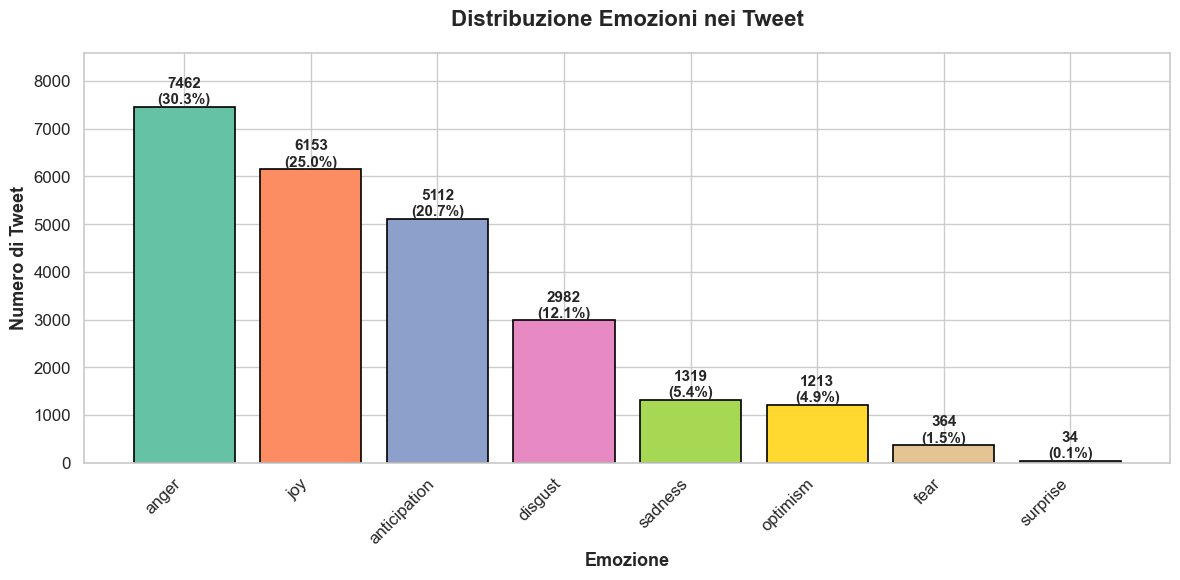

In [5]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

emotion_counts = df['emotion'].value_counts()

#Creazione grafico
fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette("Set2", len(emotion_counts))

bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', linewidth=1.2)

#Aggiunti i valori sopra le barre
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribuzione Emozioni nei Tweet', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Emozione', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero di Tweet', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(emotion_counts.values) * 1.15) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Grafico a barre per distribuzione delle emozioni per sentiment

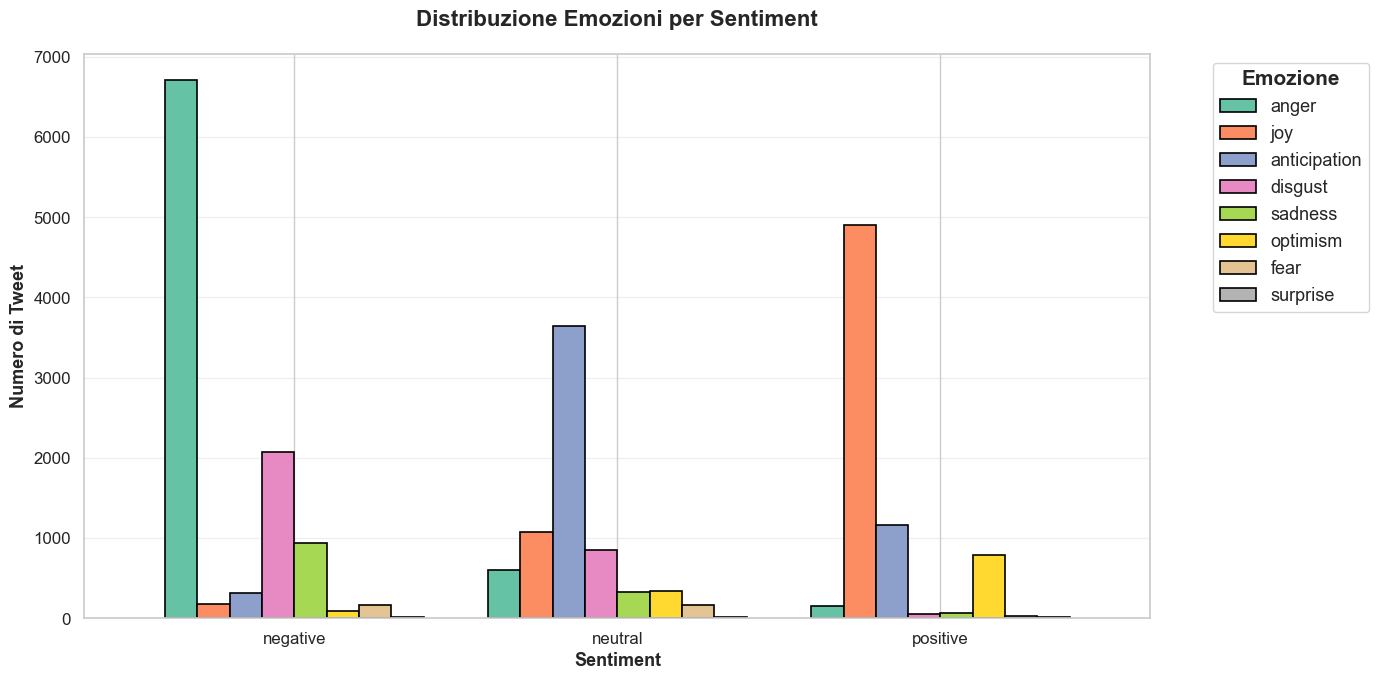

In [6]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

emotion_by_sentiment = pd.crosstab(df['sentiment'], df['emotion'])
emotion_by_sentiment = emotion_by_sentiment.reindex(['negative', 'neutral', 'positive'])

#Stesso ordine di prima per mantenere stessi colori
emotion_order = df['emotion'].value_counts().index.tolist()
emotion_by_sentiment = emotion_by_sentiment[emotion_order]

colors = sns.color_palette("Set2", len(emotion_by_sentiment.columns))

fig, ax = plt.subplots(figsize=(14, 7))

emotion_by_sentiment.plot(kind='bar', ax=ax, width=0.8, color=colors, edgecolor='black', linewidth=1.2)

ax.set_title('Distribuzione Emozioni per Sentiment', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero di Tweet', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
legend = ax.legend(title='Emozione', bbox_to_anchor=(1.05, 1), loc='upper left', 
                   fontsize=13, title_fontsize=15)
legend.get_title().set_fontweight('bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Funzione di preprocessing che fa tokenizzazione: elimina le menzioni, toglie #, elimina i link e converte le emoji

In [7]:
import emoji
from nltk.tokenize import TweetTokenizer
import string

def preprocess_for_word2vec(text):

    #Conversione emoji
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    #Tokenizzazione
    tknzr = TweetTokenizer(preserve_case=False, reduce_len=True)
    tokens = tknzr.tokenize(text)
    
    #Filtraggio
    cleaned_tokens = []
    for token in tokens:
        if token.startswith('@'):
            continue
        if token.startswith('http') or token.startswith('www'):
            continue
        if token.startswith('#'):
            token = token[1:]
            if not token:
                continue
        if token in string.punctuation:
            continue
        if token.isdigit():
            continue
        
        if token.strip():
            cleaned_tokens.append(token)
    
    return cleaned_tokens

Divisione del dataset e applico funzione di tokenizzazione

In [8]:
from sklearn.model_selection import train_test_split

#Split del dataset
target = 'sentiment'

X = df['Text'] 
y = df[target]

print(f"\nTarget: {target}")
print(f"Dataset size: {len(X)}")
print(f"\nDistribuzione classi:")
print(y.value_counts())
print()

#Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

#Train set e validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 = 0.15 del totale
    random_state=42,
    stratify=y_temp
)

print(f"Split completato:")
print(f"  Train:      {len(X_train)} tweet ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val)} tweet ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test)} tweet ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Totale:     {len(X_train) + len(X_val) + len(X_test)} tweet")

print(f"\nDistribuzione classi nei set:")
print(f"\nTrain:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nValidation:")
print(y_val.value_counts(normalize=True) * 100)
print(f"\nTest:")
print(y_test.value_counts(normalize=True) * 100)

#Applicazione della tokenizzazione
print("\nPreprocessing train set...")
X_train_tokens = X_train.apply(preprocess_for_word2vec)

print("Preprocessing validation set...")
X_val_tokens = X_val.apply(preprocess_for_word2vec)

print("Preprocessing test set...")
X_test_tokens = X_test.apply(preprocess_for_word2vec)


train_lengths = X_train_tokens.apply(len)
val_lengths = X_val_tokens.apply(len)
test_lengths = X_test_tokens.apply(len)

print(f"\nStatistiche token:")
print(f"  Train:      media={train_lengths.mean():.2f}, min={train_lengths.min()}, max={train_lengths.max()}")
print(f"  Validation: media={val_lengths.mean():.2f}, min={val_lengths.min()}, max={val_lengths.max()}")
print(f"  Test:       media={test_lengths.mean():.2f}, min={test_lengths.min()}, max={test_lengths.max()}")

#Controlla tweet vuoti
print(f"\nTweet vuoti:")
print(f"  Train:      {(train_lengths == 0).sum()}")
print(f"  Validation: {(val_lengths == 0).sum()}")
print(f"  Test:       {(test_lengths == 0).sum()}")

#Esempi
print("ESEMPI PREPROCESSING (Train set)")

for i in range(3):
    idx = X_train_tokens.index[i]
    print(f"\n{i+1}. Sentiment: {y_train.iloc[i]}")
    print(f"   Originale ({len(X_train.iloc[i])} char):")
    print(f"   {X_train.iloc[i][:80]}...")
    print(f"   Tokens ({len(X_train_tokens.iloc[i])}):")
    print(f"   {X_train_tokens.iloc[i][:12]}...")



Target: sentiment
Dataset size: 24639

Distribuzione classi:
sentiment
negative    10483
positive     7167
neutral      6989
Name: count, dtype: int64

Split completato:
  Train:      17257 tweet (70.0%)
  Validation: 3686 tweet (15.0%)
  Test:       3696 tweet (15.0%)
  Totale:     24639 tweet

Distribuzione classi nei set:

Train:
sentiment
negative    42.545054
positive    29.089645
neutral     28.365301
Name: proportion, dtype: float64

Validation:
sentiment
negative    42.539338
positive    29.083017
neutral     28.377645
Name: proportion, dtype: float64

Test:
sentiment
negative    42.559524
positive    29.085498
neutral     28.354978
Name: proportion, dtype: float64

Preprocessing train set...
Preprocessing validation set...
Preprocessing test set...

Statistiche token:
  Train:      media=23.17, min=1, max=70
  Validation: media=23.21, min=1, max=60
  Test:       media=23.20, min=1, max=63

Tweet vuoti:
  Train:      0
  Validation: 0
  Test:       0
ESEMPI PREPROCESSING (Trai

Train di Word2Vec

In [9]:
from gensim.models import Word2Vec
import time

tokenized_tweets = X_train_tokens.tolist()

print(f"\nParametri Word2Vec:")
print(f"  Documenti training: {len(tokenized_tweets)}")
print(f"  Vector size: 200 dimensioni")
print(f"  Window: 3 parole contesto")
print(f"  Min count: 3 occorrenze minime")

#Train Word2Vec
print("\nTraining in corso...")
start_time = time.time()

w2v_model = Word2Vec(
    sentences=tokenized_tweets,   
    vector_size=200,               
    window=3,                      
    min_count=3,                  
    workers=4,                     
    sg=1,                         
    epochs=20,                  
    seed=42                      
)

training_time = time.time() - start_time

print(f"\nWord2Vec trained in {training_time:.2f} secondi!")
print(f"  Vocabulary size: {len(w2v_model.wv):,} parole uniche")
print(f"  Vector dimensionality: {w2v_model.wv.vector_size}")



Parametri Word2Vec:
  Documenti training: 17257
  Vector size: 200 dimensioni
  Window: 3 parole contesto
  Min count: 3 occorrenze minime

Training in corso...

Word2Vec trained in 6.59 secondi!
  Vocabulary size: 7,936 parole uniche
  Vector dimensionality: 200


Test per Word2Vec

In [10]:
print("Test Word Embeddings")

#Test similarità semantica
test_words = [
    'good', 'bad', 'love', 'hate', 
    'great', 'terrible', 'dell', 'laptop'
]

print("\nParole simili per semantica:")
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' -->")
        for sim_word, score in similar:
            print(f"  - {sim_word}: {score:.3f}")
    else:
        print(f"\n'{word}': non nel vocabolario")

#Test emoji convertite
emoji_words = ['smiling_face_with_smiling_eyes', 'enraged_face', 'red_heart']
print("\n\nEmoji convertite:")
for emoji_word in emoji_words:
    if emoji_word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(emoji_word, topn=3)
        print(f"\n'{emoji_word}' -->")
        for sim_word, score in similar:
            print(f"  - {sim_word}: {score:.3f}")
    else:
        print(f"  '{emoji_word}': non trovata")

Test Word Embeddings

Parole simili per semantica:

'good' -->
  - glorious: 0.473
  - surprising: 0.443
  - bad: 0.442
  - disheartening: 0.428
  - promising: 0.423

'bad' -->
  - appealing: 0.584
  - unsatisfactory: 0.555
  - inferior: 0.543
  - shocking: 0.543
  - disheartening: 0.540

'love' -->
  - grinning_face_with_big_eyes: 0.516
  - eric: 0.490
  - wonderful: 0.485
  - awesome: 0.484
  - ummm: 0.481

'hate' -->
  - commercials: 0.572
  - prefer: 0.555
  - recommending: 0.554
  - accidentally: 0.554
  - insane: 0.553

'great' -->
  - wonderful: 0.528
  - amazing: 0.508
  - fantastic: 0.500
  - glorious: 0.475
  - slick: 0.469

'terrible' -->
  - shoddy: 0.631
  - shocking: 0.617
  - awful: 0.608
  - abysmal: 0.599
  - atrocious: 0.598

'dell' -->
  - delltips: 0.485
  - delllaptop: 0.472
  - dellservice: 0.465
  - cheapest: 0.459
  - amd-powered: 0.458

'laptop' -->
  - dellinspiron: 0.552
  - inspirion: 0.538
  - 3120s: 0.523
  - oct: 0.507
  - 3yrs: 0.503


Emoji convertite:


Conversione dei tweet in vettori

In [11]:
def tweet_to_vector(tokens, model):
    """Media dei word embeddings"""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.wv.vector_size)

X_train_w2v = np.array([tweet_to_vector(tokens, w2v_model) 
                        for tokens in X_train_tokens])

X_val_w2v = np.array([tweet_to_vector(tokens, w2v_model) 
                      for tokens in X_val_tokens])

X_test_w2v = np.array([tweet_to_vector(tokens, w2v_model) 
                       for tokens in X_test_tokens])

print(f"\nConversione completata!")
print(f"  X_train shape: {X_train_w2v.shape}")
print(f"  X_val shape:   {X_val_w2v.shape}")
print(f"  X_test shape:  {X_test_w2v.shape}")

train_coverage = np.count_nonzero(X_train_w2v.sum(axis=1))
val_coverage = np.count_nonzero(X_val_w2v.sum(axis=1))
test_coverage = np.count_nonzero(X_test_w2v.sum(axis=1))

print(f"\nCoverage (tweet con più di 1 parola nel vocabolario):")
print(f"  Train: {train_coverage}/{len(X_train_w2v)} ({train_coverage/len(X_train_w2v)*100:.1f}%)")
print(f"  Val:   {val_coverage}/{len(X_val_w2v)} ({val_coverage/len(X_val_w2v)*100:.1f}%)")
print(f"  Test:  {test_coverage}/{len(X_test_w2v)} ({test_coverage/len(X_test_w2v)*100:.1f}%)")


Conversione completata!
  X_train shape: (17257, 200)
  X_val shape:   (3686, 200)
  X_test shape:  (3696, 200)

Coverage (tweet con più di 1 parola nel vocabolario):
  Train: 17192/17257 (99.6%)
  Val:   3668/3686 (99.5%)
  Test:  3685/3696 (99.7%)


Training del classificatore Naive Bayes

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

clf = GaussianNB() 

start_time = time.time()
clf.fit(X_train_w2v, y_train)
training_time = time.time() - start_time
print(f"Training completato in {training_time:.2f} secondi")

#Predizioni
y_pred_val = clf.predict(X_val_w2v)
y_pred_test = clf.predict(X_test_w2v)

#Accuracy
val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nACCURACY:")
print(f"  Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test:       {test_acc:.4f} ({test_acc*100:.2f}%)")

#Classification Report sul test set
print("\nCLASSIFICATION REPORT (Test Set)")
print(classification_report(y_test, y_pred_test))

#Confusion Matrix sul test set
print("CONFUSION MATRIX (Test Set)")
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)


Training completato in 0.08 secondi

ACCURACY:
  Validation: 0.5974 (59.74%)
  Test:       0.6058 (60.58%)

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    negative       0.63      0.84      0.72      1573
     neutral       0.50      0.39      0.44      1048
    positive       0.67      0.46      0.55      1075

    accuracy                           0.61      3696
   macro avg       0.60      0.57      0.57      3696
weighted avg       0.60      0.61      0.59      3696

CONFUSION MATRIX (Test Set)
[[1329  207   37]
 [ 432  411  205]
 [ 365  211  499]]


Training del classificatore LogisticRegression

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("\nModello: Logistic Regression")
clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0
)

print("Training in corso...")
start_time = time.time()
clf.fit(X_train_w2v, y_train)
training_time = time.time() - start_time

print(f"Training completato in {training_time:.2f} secondi")

y_pred_val = clf.predict(X_val_w2v)
y_pred_test = clf.predict(X_test_w2v)

val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nACCURACY:")
print(f"  Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test:       {test_acc:.4f} ({test_acc*100:.2f}%)")

#Classification Report sul test set
print("CLASSIFICATION REPORT (Test Set)")
print(classification_report(y_test, y_pred_test))

#Confusion Matrix sul test set
print("CONFUSION MATRIX (Test Set)")
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)


Modello: Logistic Regression
Training in corso...
Training completato in 0.60 secondi

ACCURACY:
  Validation: 0.7301 (73.01%)
  Test:       0.7181 (71.81%)
CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    negative       0.76      0.88      0.82      1573
     neutral       0.61      0.47      0.53      1048
    positive       0.73      0.72      0.73      1075

    accuracy                           0.72      3696
   macro avg       0.70      0.69      0.69      3696
weighted avg       0.71      0.72      0.71      3696

CONFUSION MATRIX (Test Set)
[[1389  126   58]
 [ 333  490  225]
 [ 107  193  775]]


Training del classificatore SVM

In [42]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("\nModello: SVM con kernel RBF")
clf_svm = SVC(
    kernel='rbf',        
    C=1.0,              
    gamma='scale',     
    class_weight='balanced',
    random_state=42
)

print("Training in corso...")
start_time = time.time()
clf_svm.fit(X_train_w2v, y_train)
training_time = time.time() - start_time

print(f"Training completato in {training_time:.2f} secondi")

y_pred_val = clf_svm.predict(X_val_w2v)
y_pred_test = clf_svm.predict(X_test_w2v)

# Accuracy
val_acc = accuracy_score(y_val, y_pred_val)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\nACCURACY:")
print(f"  Validation: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test:       {test_acc:.4f} ({test_acc*100:.2f}%)")

#Classification Report sul test set
print("CLASSIFICATION REPORT (Test Set)")
print(classification_report(y_test, y_pred_test))

#Confusion Matrix sul test set
print("CONFUSION MATRIX (Test Set)")
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)


Modello: SVM con kernel RBF
Training in corso...
Training completato in 23.39 secondi

ACCURACY:
  Validation: 0.7561 (75.61%)
  Test:       0.7600 (76.00%)
CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    negative       0.82      0.85      0.83      1573
     neutral       0.65      0.62      0.64      1048
    positive       0.77      0.77      0.77      1075

    accuracy                           0.76      3696
   macro avg       0.75      0.75      0.75      3696
weighted avg       0.76      0.76      0.76      3696

CONFUSION MATRIX (Test Set)
[[1335  170   68]
 [ 217  651  180]
 [  79  173  823]]


Training della rete LSTM

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

#Preparazione dei dati in un dizionario
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

word2idx = {w: i+1 for i, w in enumerate(w2v_model.wv.index_to_key)}
vocab_size = len(word2idx) + 1


def to_seq(tokens_list, max_len=50):
    seqs = [[word2idx.get(w, 0) for w in tokens] for tokens in tokens_list]
    return pad_sequences(seqs, maxlen=max_len, padding='post')

X_train_seq = to_seq(X_train_tokens)
X_val_seq = to_seq(X_val_tokens)
X_test_seq = to_seq(X_test_tokens) 

#Matrice di embedding usando Word2Vec
emb_dim = 200
emb_matrix = np.zeros((vocab_size, emb_dim))
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        emb_matrix[idx] = w2v_model.wv[word]

#Calcolo dei class weights per gestire lo sbilanciamento
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")

#Modello con Dropout per ridurre overfitting
model = Sequential([
    Embedding(vocab_size, emb_dim, weights=[emb_matrix]),
    Dropout(0.3),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Callbacks: Early Stopping e Model Checkpoint
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

#Training
print("Inizio training...")
history_LSTM = model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

#Validation (per riferimento)
val_loss, val_acc = model.evaluate(X_val_seq, y_val_enc, verbose=0)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

#Valutazione finale sul test set
print("\nVALUTAZIONE FINALE SUL TEST SET")
test_loss, test_acc = model.evaluate(X_test_seq, y_test_enc, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


#Predizioni sul test set
y_pred = model.predict(X_test_seq, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)


#Report dettagliato
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_classes))



Class weights: {0: 0.7834831562698629, 1: 1.175144705481784, 2: 1.145883134130146}
Inizio training...
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5196 - loss: 0.9581
Epoch 1: val_loss improved from None to 0.68127, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5927 - loss: 0.8682 - val_accuracy: 0.7086 - val_loss: 0.6813
Epoch 2/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6847 - loss: 0.7455
Epoch 2: val_loss improved from 0.68127 to 0.63455, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6946 - loss: 0.7413 - val_accuracy: 0.7442 - val_loss: 0.6346
Epoch 3/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7315 - loss: 0.6880
Epoch 3: val_loss improved from 0.63455 to 0.62554, saving model to best_lstm_model.keras

Epoch 3: finishe

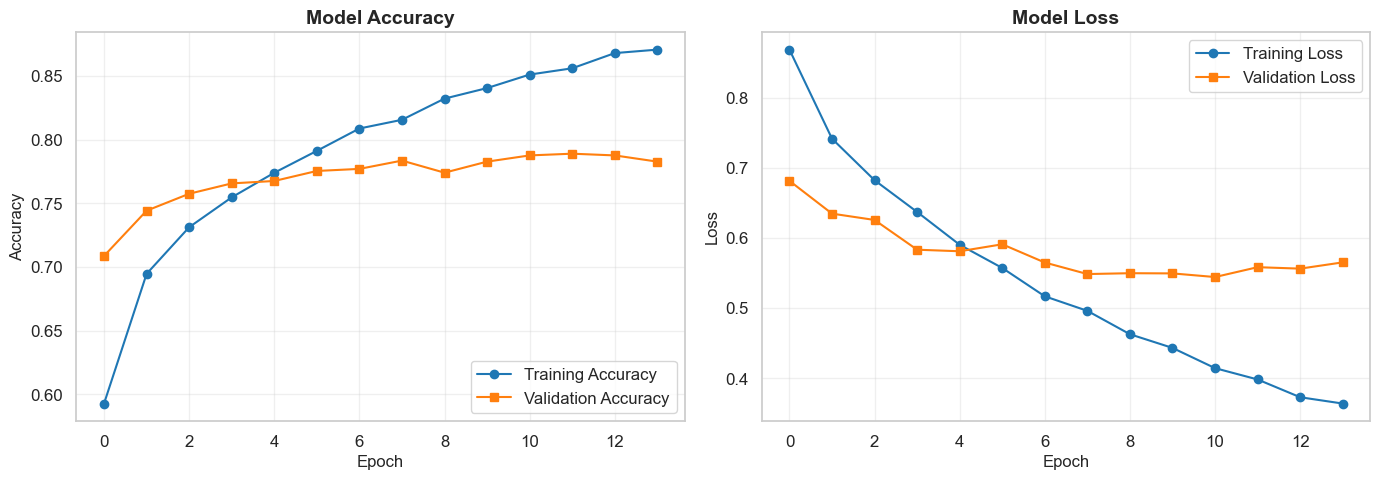


Miglior epoca: 11
Best val_loss: 0.5442
Best val_accuracy: 78.89%


In [44]:
def plot_training_LSTM_history(history):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafico Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    # Grafico Loss
    ax2.plot(history.history['loss'], label='Training Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
plot_training_LSTM_history(history_LSTM)

best_epoch = np.argmin(history_LSTM.history['val_loss']) + 1
print(f"\nMiglior epoca: {best_epoch}")
print(f"Best val_loss: {min(history_LSTM.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history_LSTM.history['val_accuracy'])*100:.2f}%")

Training della rete BI-LSTM

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

#Preparazione dei dati
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

word2idx = {w: i+1 for i, w in enumerate(w2v_model.wv.index_to_key)}
vocab_size = len(word2idx) + 1

def to_seq(tokens_list, max_len=50):
    seqs = [[word2idx.get(w, 0) for w in tokens] for tokens in tokens_list]
    return pad_sequences(seqs, maxlen=max_len, padding='post')

X_train_seq = to_seq(X_train_tokens)
X_val_seq = to_seq(X_val_tokens)
X_test_seq = to_seq(X_test_tokens)

#Matrice di embedding usando Word2Vec
emb_dim = 200
emb_matrix = np.zeros((vocab_size, emb_dim))
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        emb_matrix[idx] = w2v_model.wv[word]

#Calcolo dei class weights per gestire lo sbilanciamento
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")

#Modello con Bidirectional LSTM
model = Sequential([
    Embedding(vocab_size, emb_dim, weights=[emb_matrix]),
    Dropout(0.3),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Callbacks
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_bi-lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

#Training
print("Inizio training...")
history_BILSTM = model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

#Validation
val_loss, val_acc = model.evaluate(X_val_seq, y_val_enc, verbose=0)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

#Valutazione finale sul test set
print("\nVALUTAZIONE FINALE SUL TEST SET")
test_loss, test_acc = model.evaluate(X_test_seq, y_test_enc, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

#Predizioni sul test set
y_pred = model.predict(X_test_seq, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

#Report dettagliato
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_classes))


Class weights: {0: 0.7834831562698629, 1: 1.175144705481784, 2: 1.145883134130146}
Inizio training...
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5453 - loss: 0.9397
Epoch 1: val_loss improved from None to 0.61061, saving model to best_bi-lstm_model.keras

Epoch 1: finished saving model to best_bi-lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.6328 - loss: 0.8300 - val_accuracy: 0.7401 - val_loss: 0.6106 - learning_rate: 5.0000e-04
Epoch 2/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7269 - loss: 0.6704
Epoch 2: val_loss improved from 0.61061 to 0.56959, saving model to best_bi-lstm_model.keras

Epoch 2: finished saving model to best_bi-lstm_model.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.7276 - loss: 0.6641 - val_accuracy: 0.7572 - val_loss: 0.5696 - learning_rate: 5.0000e-04
Epoch 3/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7534 - loss: 0.6026
Epoch 3: val_loss improved from 0.56959

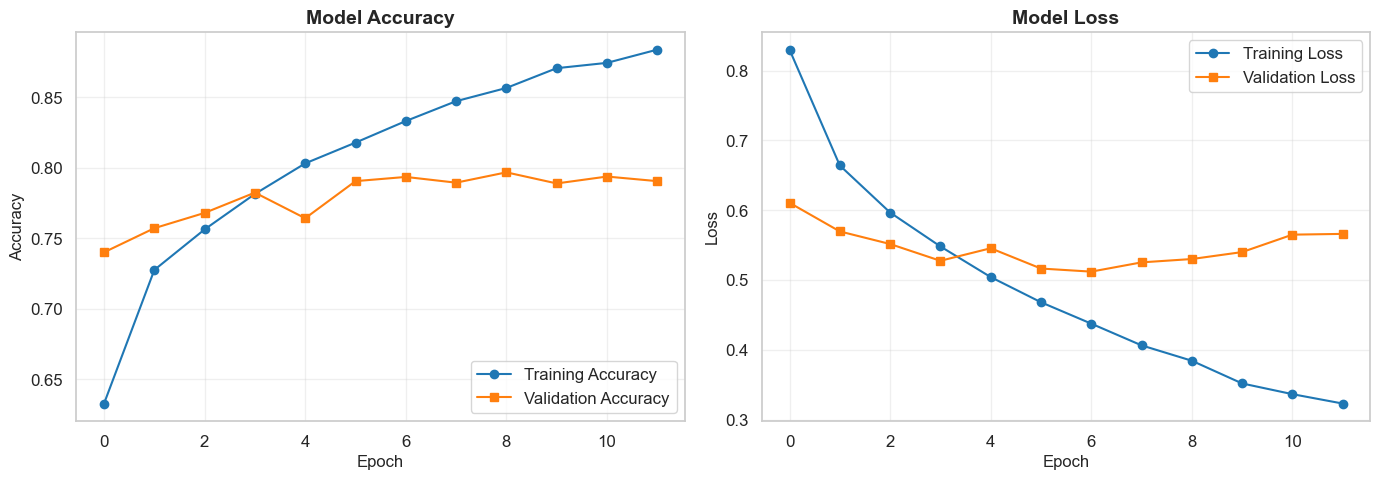


Miglior epoca: 7
Best val_loss: 0.5120
Best val_accuracy: 79.68%


In [47]:
def plot_training_BILSTM_history(history):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    #Grafico Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    #Grafico Loss
    ax2.plot(history.history['loss'], label='Training Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
plot_training_BILSTM_history(history_BILSTM)

best_epoch = np.argmin(history_BILSTM.history['val_loss']) + 1
print(f"\nMiglior epoca: {best_epoch}")
print(f"Best val_loss: {min(history_BILSTM.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history_BILSTM.history['val_accuracy'])*100:.2f}%")

WordCloud

WORDCLOUD GENERATION - SENTIMENT ANALYSIS

  Processed 24,639 tweets
  Average tokens before: 26.9
  Average tokens after:  10.9
  Reduction: 59.3%

  Example:
    Original: @Logitech @apple @Google @Microsoft @Dell @Lenovo #WhatIf QWERTY were modified for programmers so things like brackets, parens, quotes, operators, etc. moved to the middle near G-H splitting left/right brackets to separate hands, and relieving the less dextrous pinky finger?
    Tokens:   ['whatif', 'qwerty', 'modified', 'programmers', 'brackets', 'parens', 'quotes', 'operators', 'moved', 'middle', 'near', 'g-h', 'splitting', 'left', 'right', 'brackets', 'separate', 'hands', 'relieving', 'less', 'dextrous', 'pinky', 'finger']
    Cleaned:  whatif qwerty modified programmers brackets parens quotes operators moved middle near g-h splitting left right brackets separate hands relieving less dextrous pinky finger
  Negative  : 10,483 tweets
  Neutral   :  6,989 tweets
  Positive  :  7,167 tweets


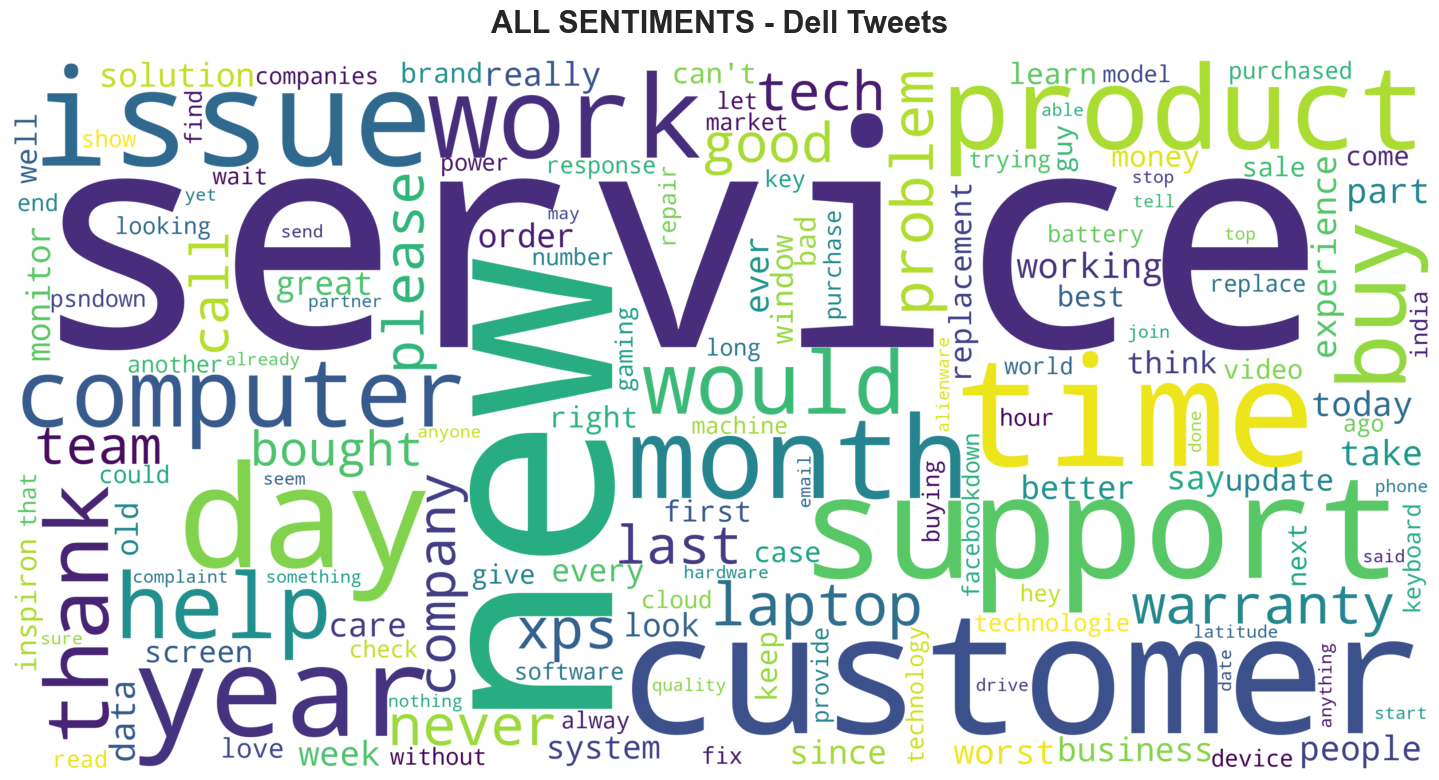

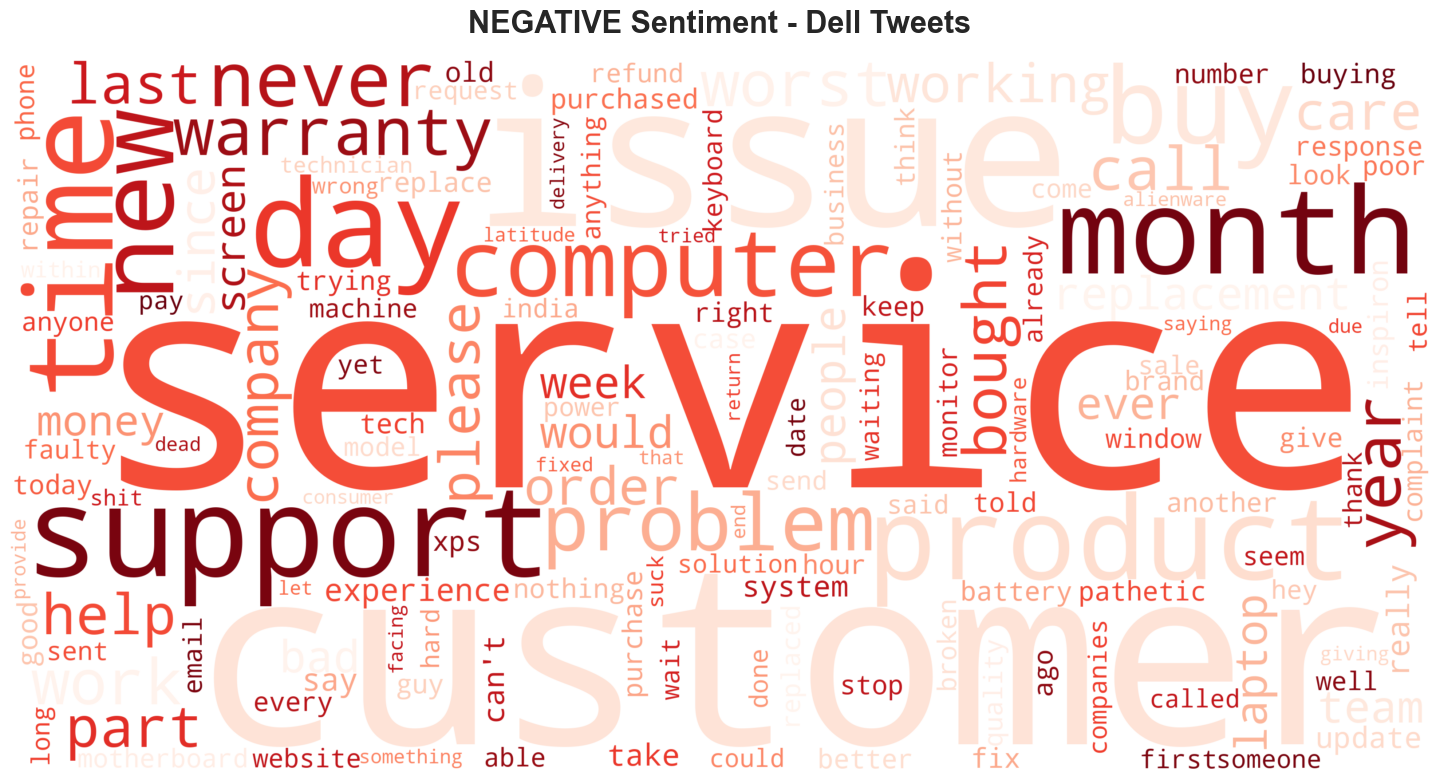

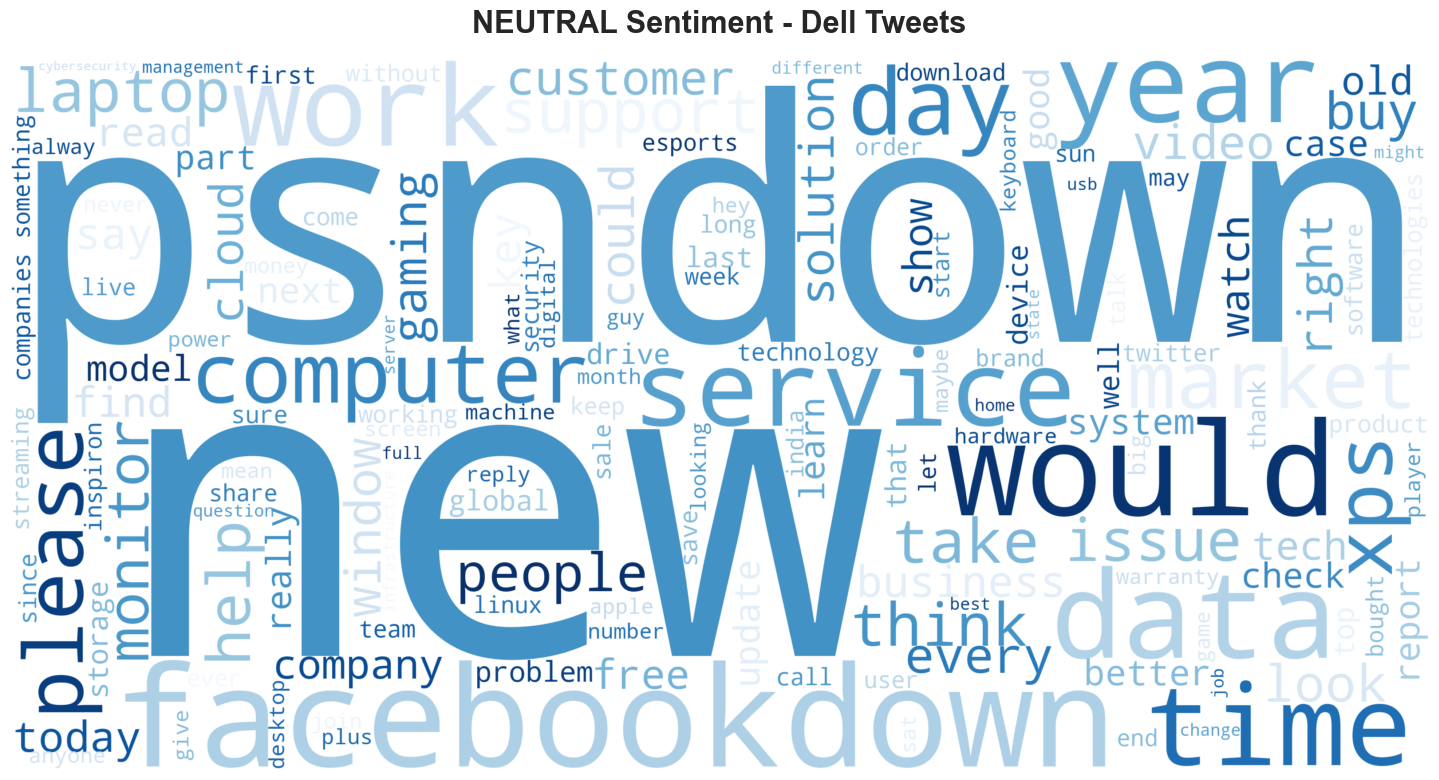

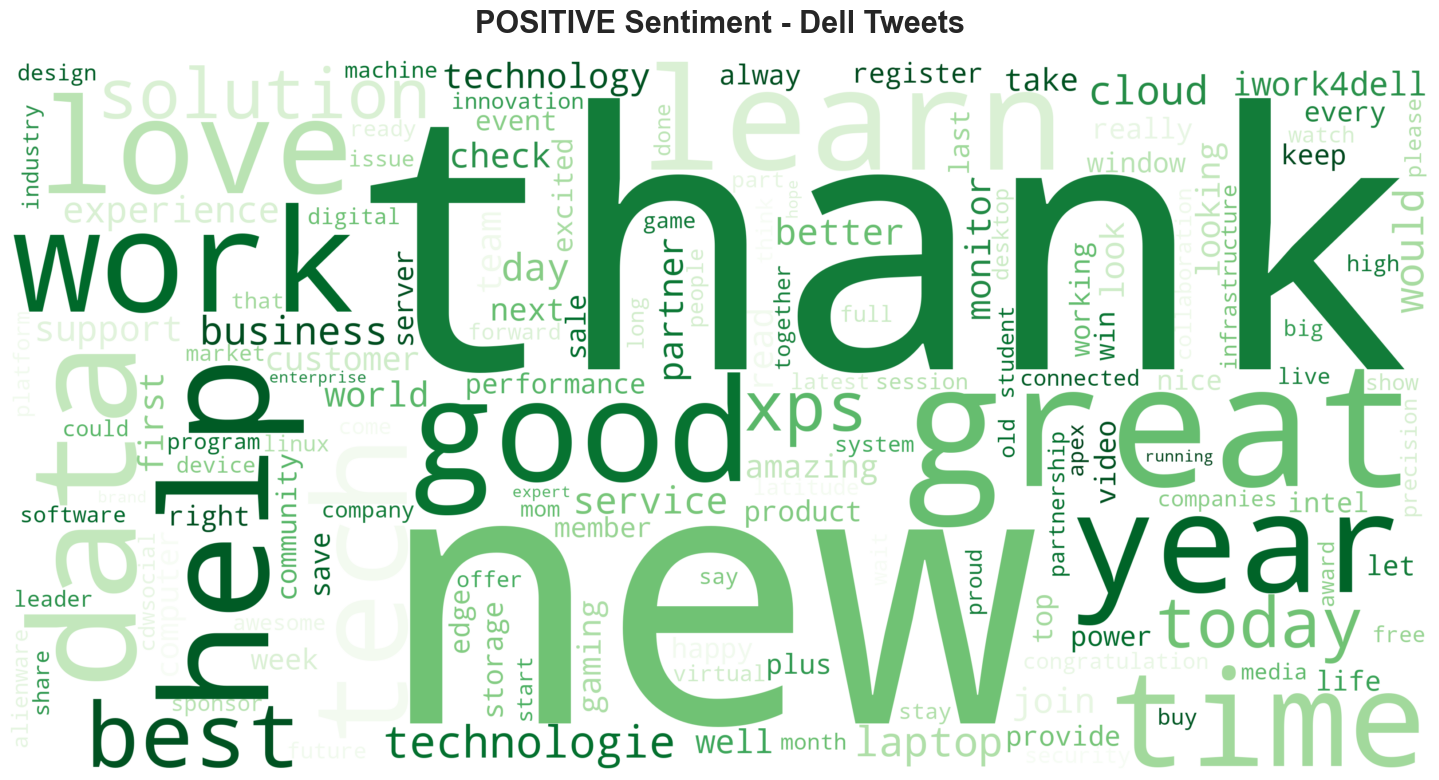


Top 15 words by sentiment:

ALL:
  service          2175
  new              1864
  support          1467
  customer         1453
  time             1239
  buy              1105
  work             1026
  would             999
  help              966
  issue             921
  days              851
  computer          828
  laptops           814
  never             805
  xps               803

NEGATIVE:
  service          1907
  customer         1241
  support          1108
  buy               884
  new               850
  issue             781
  time              777
  days              706
  never             674
  warranty          665
  worst             628
  computer          599
  months            597
  bought            572
  product           571

NEUTRAL:
  new               346
  psndown           330
  facebookdown      325
  would             291
  data              261
  time              186
  work              185
  please            178
  xps               172
  market 

In [ ]:
import pandas as pd
import emoji
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

def preprocess_for_wordcloud(text):
    
    #Rimozione emoji
    text = emoji.replace_emoji(text, replace='')
    
    #Tokenizzazione
    tknzr = TweetTokenizer(preserve_case=False, reduce_len=True)
    tokens = tknzr.tokenize(text)
    
    #Caricamento stop words inglesi
    stop_words = set(stopwords.words('english'))
    
    #Aggiunta stop words custom
    custom_stopwords = {
        'rt', 'via', 'retweet', 'retweeted',
        'get', 'got', 'getting',
        'go', 'going', 'goes', 'gone',
        'use', 'using', 'used', 'uses',
        'make', 'makes', 'making', 'made',
        'want', 'wanted', 'wants',
        'need', 'needs', 'needed',
        'know', 'knows', 'known',
        'thing', 'things',
        'like', 'likes', 'liked',
        'see', 'seen', 'saw',
        'one', 'two', 'also', 'much', 'many',
        'even', 'back', 'still', 'way', 'etc.', 'etc',
        'dell', 'laptop','laptops','computer','computers'  #Dell e laptop/computer aggiunti perchè molto frequenti e poco informativi
    }
    
    stop_words.update(custom_stopwords)
    
    cleaned_tokens = []
    for token in tokens:
        #Rimozione mentions
        if token.startswith('@'):
            continue
        
        #Rimozione URL
        if token.startswith('http') or token.startswith('www'):
            continue
        
        #Rimozione # dagli hashtag 
        if token.startswith('#'):
            token = token[1:]  
            if not token:      
                continue
        
        #Rimozione punteggiatura
        if all(char in string.punctuation for char in token):
            continue
        
        #Rimozione numeri
        if token.isdigit():
            continue
        
        #Rimozione stopwords 
        if token.lower() in stop_words:
            continue
        
        #Rimozione parole troppo corte (< 3 caratteri)
        if len(token) < 3:
            continue
        
        if token.strip():
            cleaned_tokens.append(token)
    
    return cleaned_tokens

print("WORDCLOUD GENERATION - SENTIMENT ANALYSIS")

df['tokens'] = df['Text'].apply(preprocess_for_wordcloud)
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

avg_tokens_before = df['Text'].str.split().str.len().mean()
avg_tokens_after = df['tokens'].str.len().mean()

print(f"\n  Processed {len(df):,} tweets")
print(f"  Average tokens before: {avg_tokens_before:.1f}")
print(f"  Average tokens after:  {avg_tokens_after:.1f}")
print(f"  Reduction: {((avg_tokens_before - avg_tokens_after) / avg_tokens_before * 100):.1f}%")

print(f"\n  Example:")
print(f"    Original: {df['Text'].iloc[0]}")
print(f"    Tokens:   {df['tokens'].iloc[0]}")
print(f"    Cleaned:  {df['cleaned_text'].iloc[0]}")

#Raggruppamento per sentiment
texts_by_sentiment = {
    'negative': [],
    'neutral': [],
    'positive': []
}

for sentiment in ['negative', 'neutral', 'positive']:
    tweets = df[df['sentiment'] == sentiment]['cleaned_text'].tolist()
    texts_by_sentiment[sentiment] = tweets
    print(f"  {sentiment.capitalize():<10}: {len(tweets):>6,} tweets")

all_text = ' '.join(df['cleaned_text'].tolist())

sentiment_config = {
    'all': {'colormap': 'viridis', 'title': 'ALL SENTIMENTS'},
    'negative': {'colormap': 'Reds', 'title': 'NEGATIVE Sentiment'},
    'neutral': {'colormap': 'Blues', 'title': 'NEUTRAL Sentiment'},
    'positive': {'colormap': 'Greens', 'title': 'POSITIVE Sentiment'}
}

#WordCloud generale con tutti i sentiments
fig, ax = plt.subplots(figsize=(16, 8))

wordcloud_all = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=set(),
    colormap='viridis',
    max_words=150,
    relative_scaling=0.7,
    min_font_size=14,
    collocations=False,
    prefer_horizontal=0.7,
    mode='RGBA',
    scale=2
).generate(all_text)

ax.imshow(wordcloud_all, interpolation='bilinear')
ax.axis('off')
ax.set_title('ALL SENTIMENTS - Dell Tweets', fontsize=22, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#WordCloud sentiment negativo
fig, ax = plt.subplots(figsize=(16, 8))

text_negative = ' '.join(texts_by_sentiment['negative'])
wordcloud_negative = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=set(),
    colormap='Reds',
    max_words=150,
    relative_scaling=0.7,
    min_font_size=14,
    collocations=False,
    prefer_horizontal=0.7,
    mode='RGBA',
    scale=2
).generate(text_negative)

ax.imshow(wordcloud_negative, interpolation='bilinear')
ax.axis('off')
ax.set_title('NEGATIVE Sentiment - Dell Tweets', fontsize=22, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#WordCloud sentiment neutrale
fig, ax = plt.subplots(figsize=(16, 8))

text_neutral = ' '.join(texts_by_sentiment['neutral'])
wordcloud_neutral = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=set(),
    colormap='Blues',
    max_words=150,
    relative_scaling=0.7,
    min_font_size=14,
    collocations=False,
    prefer_horizontal=0.7,
    mode='RGBA',
    scale=2
).generate(text_neutral)

ax.imshow(wordcloud_neutral, interpolation='bilinear')
ax.axis('off')
ax.set_title('NEUTRAL Sentiment - Dell Tweets', fontsize=22, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#WordCloud sentiment positivo
fig, ax = plt.subplots(figsize=(16, 8))

text_positive = ' '.join(texts_by_sentiment['positive'])
wordcloud_positive = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=set(),
    colormap='Greens',
    max_words=150,
    relative_scaling=0.7,
    min_font_size=14,
    collocations=False,
    prefer_horizontal=0.7,
    mode='RGBA',
    scale=2
).generate(text_positive)

ax.imshow(wordcloud_positive, interpolation='bilinear')
ax.axis('off')
ax.set_title('POSITIVE Sentiment - Dell Tweets', fontsize=22, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#Top 15 parole per sentiment
print("\nTop 15 words by sentiment:")
for sentiment in ['all', 'negative', 'neutral', 'positive']:
    if sentiment == 'all':
        tokens = [token for tokens_list in df['tokens'] for token in tokens_list]
    else:
        tokens = [token for tokens_list in df[df['sentiment'] == sentiment]['tokens'] 
                  for token in tokens_list]
    
    counter = Counter(tokens)
    print(f"\n{sentiment.upper()}:")
    for word, count in counter.most_common(15):
        print(f"  {word:<15} {count:>5}")